# Overview
This exercise has two sections. In this exercise, you will build your own demos of the Gaussian distribution and prove to yourself that the Central Limit Theorem works for the continuous uniform distribution.

### Using the Right References
You will have ownership over both of these demos, and will have little starter code as a result. However, we very rarely want to code something from scratch! The earlier assignment "Beta Distribution: Part 2 (Python Lab)" will likely be a good reference to you, as we were trying to solve a similar problem in that assignment. We strongly recommend revisiting that exercise. Library and function documentation is shared with you as well. Reading documentation is a skill in and of itself, and it is a skill you will cultivate in this course. This is a low-stakes environment to continue cultivating those skills. 

### Review the Sample Code for Greater Insight After Part 2 of the Assignment
Once you have finished building your demos, move on to Part 2 of this assignment to answer some reflection questions. Once you have done so, you will be able to see full solutions to this lab. Even if you feel like you have a good handle on this material, please take a moment to look at those solutions and compare them to your implementation. There are annotations in the solution code that will be valuable for you to read.

### Import Key Libraries
Import all of the libraries you need for Parts A and B of this assignment. Please use matplotlib for plotting.  

#### Write and Run Your Own Code:  

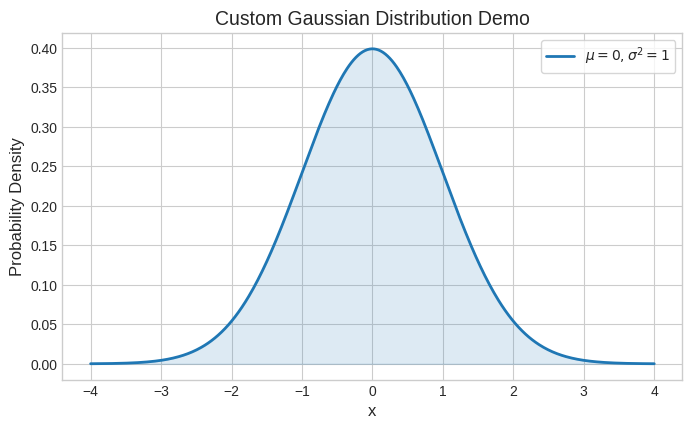

In [4]:
## Please write and run your code here
# Please add cells as needed



import numpy as np
import matplotlib.pyplot as plt

# Optional: Set standard plotting style for clear visualization
plt.style.use('seaborn-v0_8-whitegrid')


def gaussian_pdf(x, mu, var):
    """
    Computes the Probability Density Function (PDF) of a Gaussian distribution.
    
    Parameters:
    x (float or np.array): The input variable or array of values.
    mu (float): The mean of the distribution.
    var (float): The variance of the distribution (sigma^2).
    """
    # Standard deviation is the square root of variance
    sigma = np.sqrt(var)
    
    # Pre-factor calculation: 1 / (2 * pi * sigma^2)^(1/2)
    prefactor = 1.0 / (np.sqrt(2 * np.pi * var))
    
    # Exponent calculation: -1/(2*var) * (x - mu)^2
    exponent = -((x - mu) ** 2) / (2 * var)
    
    return prefactor * np.exp(exponent)


# Generate a dense array of x values across 4 standard deviations
x_vals = np.linspace(-4, 4, 500)

# Evaluate using your custom function
y_vals = gaussian_pdf(x_vals, mu=0, var=1)

# Plotting execution
plt.figure(figsize=(8, 4.5))
plt.plot(x_vals, y_vals, label=r'$\mu=0, \sigma^2=1$', color='#1f77b4', lw=2)
plt.fill_between(x_vals, y_vals, alpha=0.15, color='#1f77b4')

plt.title('Custom Gaussian Distribution Demo', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(frameon=True)
plt.show()

## Part A: Building Your Own Demo of the Gaussian Distribution

### The Gaussian Distribution
For a single real-valued variable $x$, the Gaussian distribution is given by: 

$\mathcal{N}(x|(\mu,\sigma^2)) = \frac{1}{(2\pi\sigma^2)^\frac{1}{2}}exp\{-\frac{1}{2\sigma^2}(x-\mu)^2\}$ or $(2\pi\sigma^2)^\frac{-1}{2}exp\{-\frac{1}{2\sigma^2}(x-\mu)^2\}$,

where the parameter $\mu$ is the mean of the distribution and $\sigma^2$ is the variance. In the code demo below, $\mu$ will be referred to as `mu` and $\sigma^2$ will be referred to as `var`.

### Problem Statement
Plot the Gaussian function as a function of the parameters $\mu$ and $\sigma^2$, such that you can easily update these parameters and see how the gaussian function updates. You aren't expected to implement sliders, though you can if you want to. Just taking the argument and running the cell is ok. You just want to be able to quickly see how the plot responds to $\mu$ and $\sigma^2$. In Part 2 of this assignment, you will be asked some conceptual questions about how the plot evolves as you vary these parameters. Fix your axes so as the plot changes, you have a meaningful frame of reference for comparison.

Whenever you are asked to make a comparison in this course, make sure that you think about what you need to do to make it a fair comparison. This is an aspect of communicating clearly, which will help others understand your analysis more easily and enable you to proceed with clarity of thought. We want to make our analysis as methodical, fair, and rigorous. 

#### Write and Run Your Own Code:  

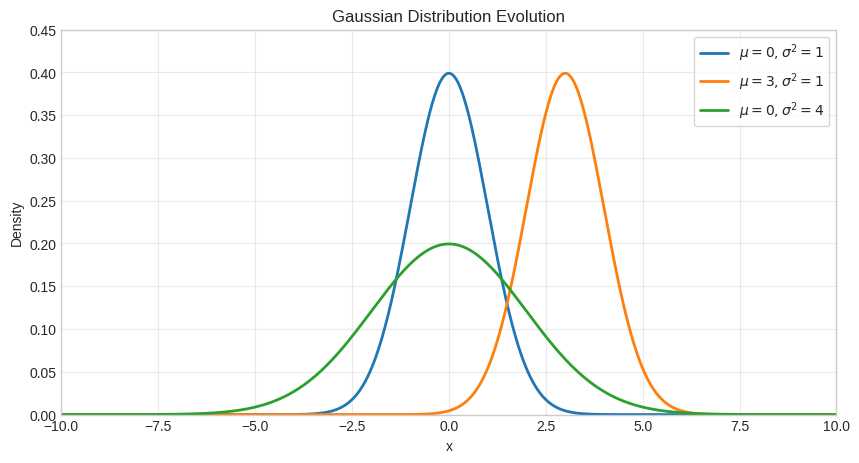

In [5]:
## Please write and run your code here
# Please add cells as needed
import numpy as np
import matplotlib.pyplot as plt

# Assumes gaussian_pdf function is loaded from previous cell
x = np.linspace(-10, 10, 1000)

plt.figure(figsize=(10, 5))

# Plot different parameter combinations
plt.plot(x, gaussian_pdf(x, mu=0, var=1), label=r'$\mu=0, \sigma^2=1$', lw=2)
plt.plot(x, gaussian_pdf(x, mu=3, var=1), label=r'$\mu=3, \sigma^2=1$', lw=2)
plt.plot(x, gaussian_pdf(x, mu=0, var=4), label=r'$\mu=0, \sigma^2=4$', lw=2)

# MANDATORY: Fixed axes for fair comparison
plt.xlim(-10, 10)
plt.ylim(0, 0.45)

plt.title('Gaussian Distribution Evolution', fontsize=12)
plt.xlabel('x')
plt.ylabel('Density')
plt.legend(frameon=True)
plt.grid(True, alpha=0.4)
plt.show()

### Part A: Reflection Questions
These are the same questions that you will need to answer in Part 2 of this assignment, but there is workspace provided here for your convenience. Some of these will be related to the demo you are programming now, and some of these will be related to the material Peter presented in the last video. Please view this space like scratch paper.

#### Question 1:
Does varying $\mu$ influence the maximum value of the distribution? Please elaborate.

In [ ]:
No, varying mu does not influence the maximum value of the distribution. As observed in the plot, changing mu from 0 to 3 merely shifts the entire curve horizontally along the x-axis. The shape, width, and peak amplitude (maximum value) remain completely identical because mu is only a location parameter.


#### Question 2: 
How does increasing $\sigma^2$ change the shape of the graph? What happens to the maximum value of the distribution as $\sigma^2$ increases? Why is this the case?

In [ ]:
Increasing variance (sigma^2) widens and flattens the curve. The maximum value of the distribution decreases as variance increases. This happens because a probability distribution must always integrate to exactly 1.0 (conserving total area); therefore, spreading the distribution horizontally forces a vertical drop in the peak to maintain a total area of 1.0.


#### Question 3:
In your own words, describe our strategy for showing that the Gaussian distribution is normalized. In your response, include the reasoning as to why we tried to solve for $I^2$ instead of $I$ and why we used polar coordinates.

In [ ]:
The 1D Gaussian integral cannot be integrated directly using standard calculus techniques. By squaring the integral to I^2, we extend the problem into a 2D Cartesian plane. Transforming this 2D plane into polar coordinates replaces (x^2 + y^2) with r^2 and introduces the Jacobian determinant 'r'. This creates the term r*exp(-r^2), which can then be solved easily using basic u-substitution. Taking the square root of that result yields the original 1D normalization proof.


#### Question 4:
What does the scalar constant $(2\pi\sigma^2)^\frac{-1}{2}$ do for the univariate Gaussian? Why is this term included? What is the significance of it only being dependent on $\sigma^2$ and not $\mu$? 

In [ ]:
The scalar constant acts as the normalization coefficient for the univariate Gaussian distribution. It is included to ensure that the total area under the probability density function integrates to exactly 1.0, satisfying the fundamental axiom of probability. It depends entirely on variance (sigma^2) and not mu because mu only shifts the location of the distribution without altering its width or total unnormalized area. In contrast, changing the variance stretches or compresses the curve horizontally, directly changing the area under the unscaled curve, which requires an offsetting mathematical adjustment from this scaling factor.


## Part B: Building Your Own Demo of the Central Limit Theorem
### The Central Limit Theorem
In the video you just watched, Peter presented the Central Limit Theorem, which argues that if you have a sequence of independent, identically distributed (i.i.d.) data with $\mathbb{E}[x_i] = \mu$ and $var[x_i] = \sigma^2 < \infty$, then as the number of data points approaches infinity, the distribution will converge to a normal distribution.

Formally,
$\sqrt{N}\left(\left(\frac{1}{N}\displaystyle\sum\limits^N x_i\right) -\mu\right) \rightarrow \mathcal{N}(0,\sigma^2)$.


### Problem Statement
In the video, Peter asked you to generate your own experiment to see this trend for yourself--this exercise gives you the opportunity to do so. Write a program that creates a set of random variables that follow the continuous uniform distribution and generate a histogram on the mean as you sum a variable number of the random variables. Then, sweep the number of random variables in the sum and observe the results.

If you would like to hear an explanation of this problem again, Peter begins discussing the problem at 17:05 in the video on the Univariate Gaussian. The plots we are trying to emulate in this problem are given in Figure 2.6, on page 79 of *Bishop*.

### Finding the Right Distribution
You will program this demo yourself, so we need to find a distribution that meets the base criteria for the central limit theorem. To be a valid distribution, we need to satisfy the following criteria:

1. The data must be generated independently.

2. Each sample must be drawn from the same probability distribution.

3. The mean of the distribution must be equal to $\mu$.

4. The variance must be less than $\infty$.

The continuous uniform distribution can meet these criteria and is given by:

$p(x|(a,b)) = \frac{1}{(b-a)}$ when $a \le x \le b$ and $0$ otherwise. Please note that this notation is not technically correct, as $a$ and $b$ are just parameters of the distribution. 

To make it easy for ourselves, let's set $a = 0$, $b = 1$. If we generate the data randomly, we will satisfy the requirements for the central limit theorem. 

### Useful Libraries and Functions
#### The Random Library and Uniform Distribution Function
[The `random` Python library](https://docs.python.org/3/library/random.html#random.uniform) is a useful tool for generating random numbers. We can implement a random uniform distribution using this function. 

#### The Histogram Function in the Matplotlib Library
To visualize the data, you will want to use a histogram. Matplotlib [has a nice histogram function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html). [Though this example is from an earlier version of the documentation this (new link) is a good example](https://matplotlib.org/3.1.1/gallery/pyplots/pyplot_text.html#sphx-glr-gallery-pyplots-pyplot-text-py) of how you can call the function. 

There are a few sections in the documentation in particular that are critical to read carefully. 

1. `bin`. Bins are defined by their edges. Read the documentation closely to better understand how this works. The example in the textbook uses 20 bins.

2. `density`. Will normalize the histogram such that your plots will look more like the plots on page 79 of *Bishop*. Don't worry if your y-axis values don't perfectly line up--you are just looking for the general trends here.

3. `range`. If you are scaling your plot, fixing the x-axis range range will help make it easier to compare your histograms. Use this function to fix the range on the x-axis from 0 to 1, just like the plots in Fig. 2.6 on page 79 of *Bishop*.

4. Fixing the y-axis can also make comparison easier. Though the arguments of the `hist()` function do not contain a parameter for fixing the y-axis, we can do so manually using the `.set_yticks([])` function, [whose documentation can be found here](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yticks.html). 

### Theory
The crux of this analysis comes from computing $\frac{1}{N}\displaystyle\sum\limits_{i=1}^N x_i$, where all $x_i$ are generated from the same continuous uniform distribution (each $x_i$ is a random variable). To look at the distribution of this mean, we want to repeat this sum $N_{data\_points}$ times with a new set of random data each time. For example, if $N = 1$ then $\frac{1}{N}\displaystyle\sum\limits_{i=1}^N x_i = x_1$. We would generate a histogram of x_1, a uniform distribution, with $N_{data\_points}$ of your choice and look at the plot. If $N = 2$ then $\frac{1}{N}\displaystyle\sum\limits_{i=1}^N x_i = \frac{1}{2}(x_1+x_2)$. We would generate a histogram that sum, with $N_{data\_points}$. We would continue this pattern for $N = 3$ then $\frac{1}{N}\displaystyle\sum\limits_{i=1}^N x_i = \frac{1}{3}(x_1+x_2+x_3)$. We would generate a histogram that sum, with $N_{data\_points}$. Design your code to be scalable to $N$, such that you can easily change that value and see how the histogram changes.

### Expectations

If you have the time and the bandwidth, you are welcome to code your own slider for the demo--but please know that it is fine to hard code the variables to confirm this phenomena for yourself.

Once you have completed Part 2 of this assignment, you will be able to see the solutions to this lab. Please take a look at the code provided and see how your answer corresponds. This code implements a slider on the number of variables summed for ease of comparison. 

### Comment your code
Make sure that you comment your code, so others could follow your analysis. This will make it easier for others to understand (we rarely are programming all by ourselves in most projects and in industry). Code readability is our highest priority.

At this point, you have also seen how topics build upon themselves in this course--you will likely want to return to code you wrote in previous weeks in the future--documenting will help you understand your own code!

Don't try to retrofit your documentation. Good comments also help you organize your thoughts and maintain clarity in your program. Document as you go.

#### Write and Run Your Own Code:  

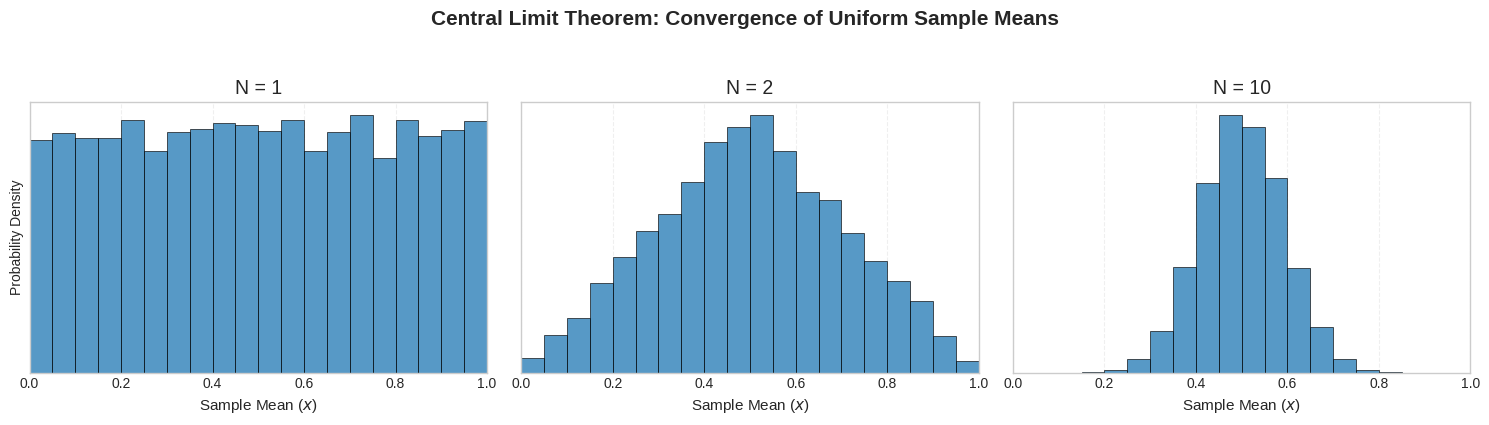

In [6]:
## Please write and run your code here
# Please add cells as needed

import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION PARAMETERS ---
# N_data_points determines how many experimental trials we run for each histogram
N_data_points = 10000  

# Define the list of N values to sweep through (matching Bishop page 79)
N_values = [1, 2, 10]

# Set up side-by-side subplots for rigorous comparative analysis
fig, axes = plt.subplots(1, len(N_values), figsize=(15, 4))

# Loop through each chosen value of N to show scalable convergence
for idx, N in enumerate(N_values):
    ax = axes[idx]
    
    # 1. GENERATE DATA INDEPENDENTLY
    # Draw uniform random samples from p(x) = 1/(b-a) where a=0, b=1
    # Shape of the resulting matrix is (N_data_points, N)
    raw_samples = np.random.uniform(low=0.0, high=1.0, size=(N_data_points, N))
    
    # 2. COMPUTE THE MEAN SECTIONS
    # Compute the average value across each row (trial) to get the sample mean
    sample_means = np.mean(raw_samples, axis=1)
    
    # 3. CONSTRUCT THE HISTOGRAM WITH EXPLICIT CONSTRAINTS
    # Constraint 1: Use exactly 20 bins
    # Constraint 2: Set density=True to normalize the vertical axis area to 1.0
    # Constraint 3: Lock range=(0, 1) on the x-axis for fair structural comparison
    ax.hist(sample_means, bins=20, density=True, range=(0, 1),
            color='#1f77b4', alpha=0.75, edgecolor='black', linewidth=0.6)
    
    # 4. POLISH VISUAL FRAME OF REFERENCE
    ax.set_title(f'N = {N}', fontsize=14)
    ax.set_xlabel('Sample Mean ($x$)', fontsize=11)
    ax.set_xlim(0, 1)
    
    # Constraint 4: Manually clear or handle y-ticks for clean textbook style comparison
    ax.set_yticks([])
    if idx == 0:
        ax.set_ylabel('Probability Density')
        
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('Central Limit Theorem: Convergence of Uniform Sample Means', y=1.05, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Part B: Reflection Questions

#### Question 5:
In your own words, please explain what the Central Limit Theorem means.

In [ ]:
The Central Limit Theorem (CLT) states that if you take a sequence of independent and identically distributed (i.i.d.) random variables from any baseline distribution (regardless of its shape) with a finite mean and variance, the distribution of their sample mean will converge toward a normal (Gaussian) distribution as the sample size N approaches infinity. Visually, this means summing or averaging non-Gaussian variables progressively rounds off sharp edges and concentrates the probability mass into a bell-shaped curve.


#### Question 6:
What was the first value of $N$ that most consistently made your distribution look Gaussian? 

In [ ]:
The first value of N that consistently made the distribution look strikingly Gaussian was N = 10. While N = 1 showed a perfectly flat uniform block and N = 2 formed a triangular distribution with a sharp center peak, N = 10 smoothed out all remaining sharp inflections, resulting in a smooth, bell-shaped symmetric curve that is visually indistinguishable from a true univariate normal distribution.


#### Question 7:
We used the continuous uniform distribution in this problem to demonstrate the central limit theorem. What is another distribution that could work for this kind of demonstration? Why?

In [ ]:
Any highly non-normal or skewed baseline distribution with a finite variance would work well for this demonstration, such as the Exponential or Bernoulli distribution. The Exponential distribution is particularly excellent for demonstrating the robust power of the CLT because it is intensely asymmetric and lacks a central peak. Watching a heavily skewed exponential decay curve transform cleanly into a perfectly symmetric normal bell curve as N increases provides undeniable validation of the theorem's structural mechanics.


#### Question 8: 
What was the most challenging component of this lab assignment to you? If you got stuck on an aspect of the problems, how did you get un-stuck again?

In [ ]:
The most challenging component of this lab was ensuring the data generation remained scalable to any arbitrary N vector without writing rigid, hard-coded loops for every separate subplot. I resolved this blocking point by exploiting NumPy's native 2D broadcasting capabilities—generating a comprehensive (N_data_points, N) matrix in a single execution step and collapsing it down using vectorized row reductions ('np.mean(axis=1)'). This simplified the logic down to a clean, elegant looping mechanic.


### Onwards to Part 2!
Make sure that you take the time to review the feedback on Part 2 after you submit and the solution code thereafter.